In [1]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(NMF)
  library(pdacR)
})

Warning message:
“replacing previous import ‘Seurat::Assays’ by ‘SummarizedExperiment::Assays’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘ggpubr::mutate’ by ‘plyr::mutate’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘Biobase::exprs’ by ‘rlang::exprs’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘readr::col_factor’ by ‘scales::col_factor’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘shiny::runExample’ by ‘shinyjs::runExample’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘limma::show’ by ‘shinyjs::show’ when loading ‘pdacR’”


## Loading data

In [2]:
met_high_df <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-high-genes-human.csv")
met_low_df  <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-low-genes-human.csv")
met_high_genes <- na.omit(met_high_df$SYMBOL)
met_low_genes  <- na.omit(met_low_df$SYMBOL)

In [3]:
missing <- intersect(met_high_genes, met_low_genes)
print(missing)

character(0)


In [4]:
file_path <- system.file("data", "TCGA_PAAD.rds", package = "pdacR")
TCGA_PAAD <- readRDS(file_path)

## Preparing TCGA

In [5]:
## Preparation of TCGA data
#RSEM counts can be rounded to the nearest integer
## RSEM assigns reads with multiple mappings -- they are counts, but a fractional amount can be assigned to a gene.
TCGA_PAAD$ex <- round(TCGA_PAAD$ex)


#remove expression of unhelpful "?" genes
#this gives the index of rows that are "?"
feat_q <- which(TCGA_PAAD$featInfo == "?")
## TCGA_PAAD is organized so that the rows of ex are in the same order as featInfo (feature info)
## and the columns of ex are in the same order as sampInfo (sample info)
# To maintain this order, removals need to be done to both 
TCGA_PAAD$ex <- TCGA_PAAD$ex[-feat_q,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-feat_q,]


#------------------

## "whitelist" filter determined by original TCGA paper
# remove the samples that are not part of the whitelist
wl_filter <- TCGA_PAAD$sampInfo$Filter_by == "whitelist"
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[wl_filter,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,wl_filter]

#------------------


# remove TCGA-US-A776 (outlier, precursor tumor)
# This sample is part of the whitelist, but is not PDAC
USA776 <- which(TCGA_PAAD$sampInfo$Tumor.Sample.ID == "TCGA-US-A776-01A")
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[-USA776,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,-USA776]

#------------------

## Some genes have 0 expression across all samples and can be removed
remove0 <- which(rowSums(TCGA_PAAD$ex) == 0)
TCGA_PAAD$ex <- TCGA_PAAD$ex[-remove0,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-remove0,]


## Check that they still have the same number of genes
dim(TCGA_PAAD$ex)

[1] 19840   149

In [6]:
dim(TCGA_PAAD$featInfo)

[1] 19840     2

## Preparing genelist (substituted with Jesse's met-high and met-low genelist)

In [7]:
metscore_genes <- data.frame(SYMBOL = met_high_genes, class = "MetHigh") %>%
  rbind(data.frame(SYMBOL = met_low_genes, class = "MetLow"))
head(metscore_genes)

,SYMBOL,class
,<chr>,<chr>
1,VMA21,MetHigh
2,RLIM,MetHigh
3,INO80C,MetHigh
4,NSDHL,MetHigh
5,GALNT1,MetHigh
6,LPIN1,MetHigh


In [8]:
rownames(metscore_genes) <- metscore_genes$SYMBOL

ex_metscore <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% metscore_genes$SYMBOL, ]
featInfo_metscore <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% metscore_genes$SYMBOL, ]

## Always want ex and featInfo to match - check the dimensions!
dim(ex_metscore)
dim(featInfo_metscore)

[1] 348 149

[1] 348   2

### Detecting the Missing genes

In [9]:
# metscore_genes has 376 values
expected_genes <- metscore_genes$SYMBOL

available_tcga_genes <- TCGA_PAAD$featInfo$SYMBOL

missing_genes <- setdiff(expected_genes, available_tcga_genes)

print(paste("Number of missing genes:", length(missing_genes)))

print(missing_genes)

[1] "Number of missing genes: 28"
 [1] "SPMIP3"    "CAVIN2"    "NABP1"     "CFAP69"    "CRACR2A"   "TENT5B"   
 [7] "ACKR3"     "TMEM238L"  "JADE3"     "SEPTIN8"   "TMPRSS11E" "SOWAHB"   
[13] "NHSL3"     "ARHGAP40"  "ENTREP1"   "NREP"      "PIEZO2"    "CCN3"     
[19] "CPED1"     "ADGRF5"    "AOPEP"     "GPR15LG"   "MALRD1"    "CLDN34"   
[25] "DENND11"   "ARHGAP44"  "KNOP1"     "FAM222B"  


## Setting up NMF

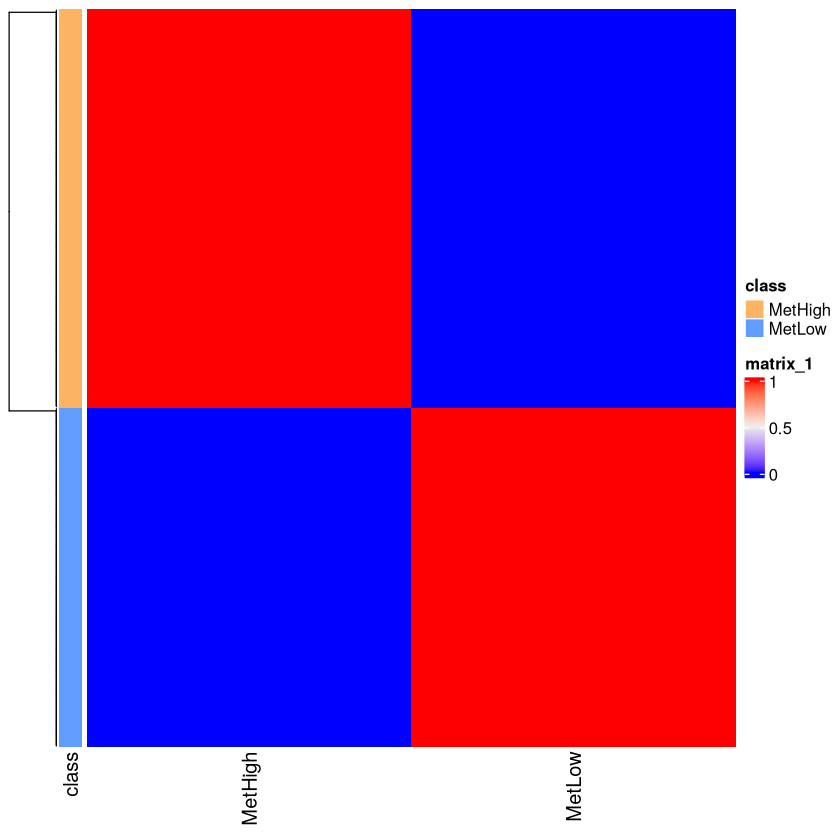

In [10]:
k = 2

RNA_val <- 1 
default_RNA <- 0.01

W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_metscore), ncol=k)

W.seed.rna[which(featInfo_metscore$SYMBOL %in% met_high_genes), 1] <- RNA_val
W.seed.rna[which(featInfo_metscore$SYMBOL %in% met_low_genes), 2]  <- RNA_val

colnames(W.seed.rna) <- c("MetHigh", "MetLow")

Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = metscore_genes[featInfo_metscore$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff") # Picked distinct colors
          )
        )
)




In [11]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_metscore))

H.seed.rna <- nmf_update.euclidean.h(ex_metscore, W.seed.rna, H.seed.rna)


In [12]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_metscore, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

## Solution to W matrix for RNA

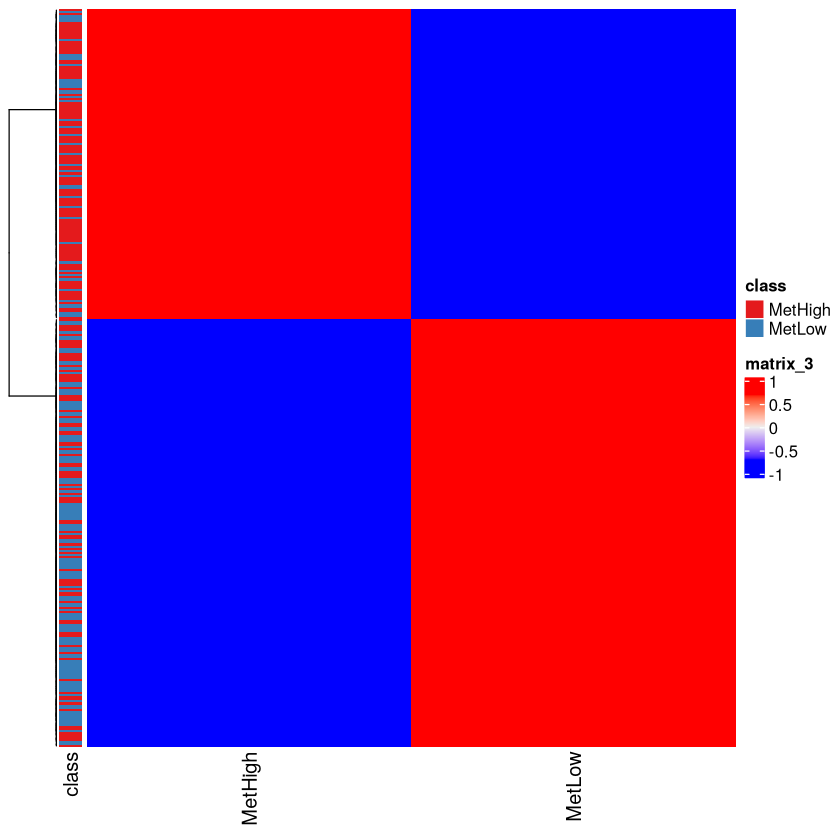

In [14]:

RNA_W <- RNA_solved@fit@W


Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,

        left_annotation = rowAnnotation(
          df = metscore_genes[featInfo_metscore$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#E41A1C", "MetLow" = "#377EB8") 
          )
        )
)

## Solution to H matrix for RNA

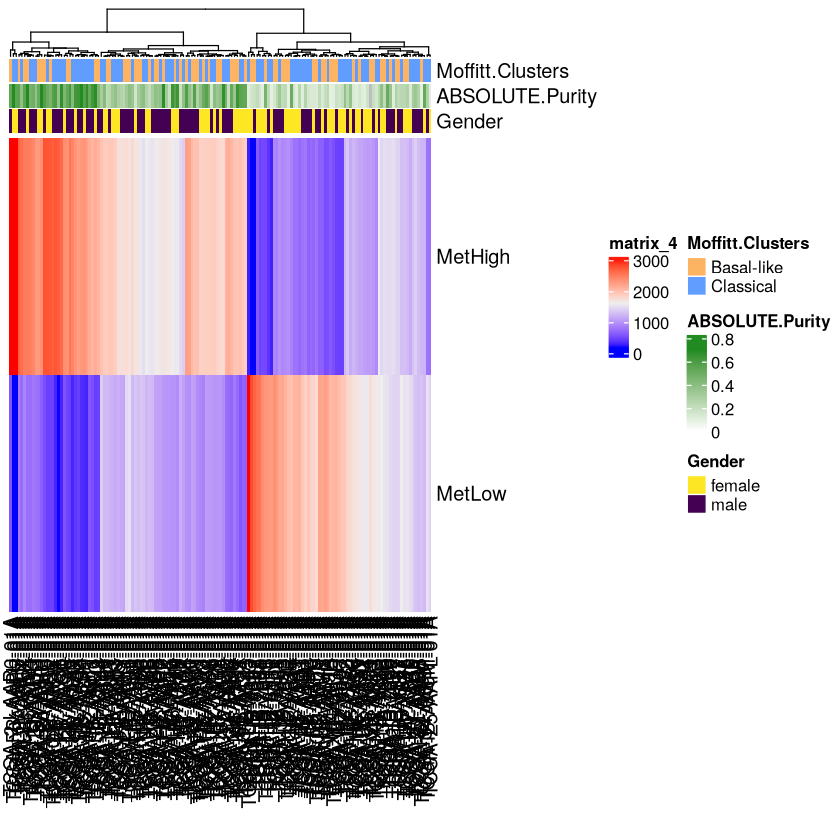

In [15]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID

rownames(RNA_H) <- c("MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        ## Keep the original patient annotations to see how they align with the scores
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

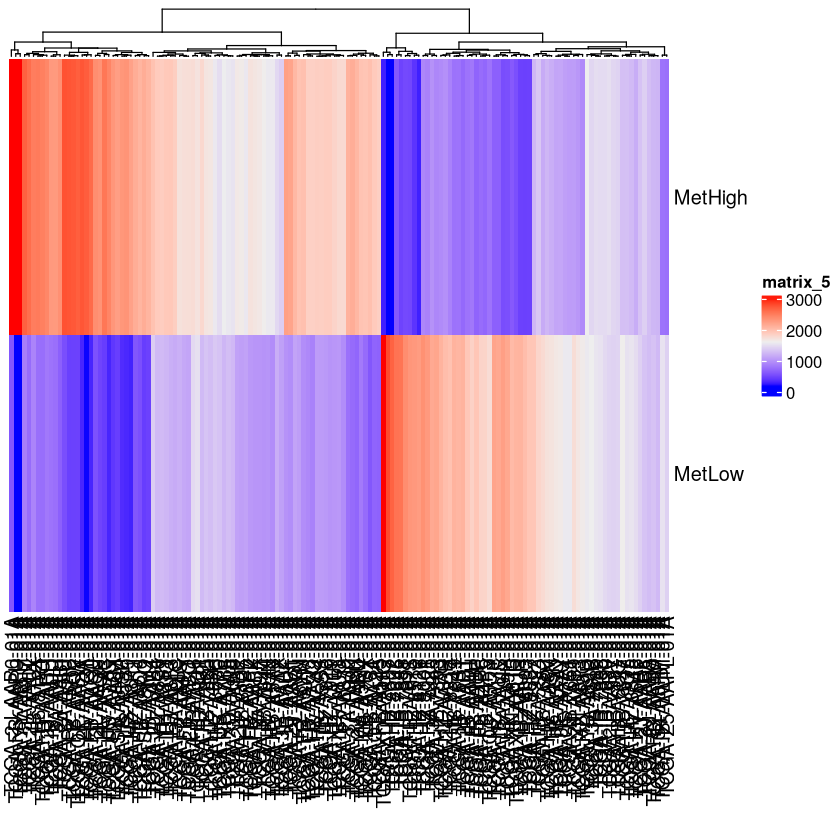

In [16]:
# No extra annotations

RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID

rownames(RNA_H) <- c("MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE)

In [21]:
# Extract the W matrix (Genes vs Signatures)
RNA_W <- RNA_solved@fit@W

# Assign the 348 gene names to the rows and the 2 signatures to the columns
rownames(RNA_W) <- rownames(ex_metscore)
colnames(RNA_W) <- c("MetHigh", "MetLow")

# 1. Open the PNG file (tall enough to fit all 348 genes)
png("MetScore_W_Matrix_Genes.png", width = 10, height = 25, units = "in", res = 300)

# 2. Plot the heatmap with tiny font for the row names
Heatmap(t(scale(t(RNA_W))), 
        cluster_columns = FALSE, 
        cluster_rows = TRUE,
        row_names_gp = grid::gpar(fontsize = 4),  ## Shrinks the gene text
        left_annotation = rowAnnotation(
          df = metscore_genes[featInfo_metscore$SYMBOL, "class", drop = FALSE],
          col = list(class = c("MetHigh" = "#E41A1C", "MetLow" = "#377EB8"))
        )
)

# 3. Save the image and close the device
dev.off()

agg_record_116517d45e50c 
                       2

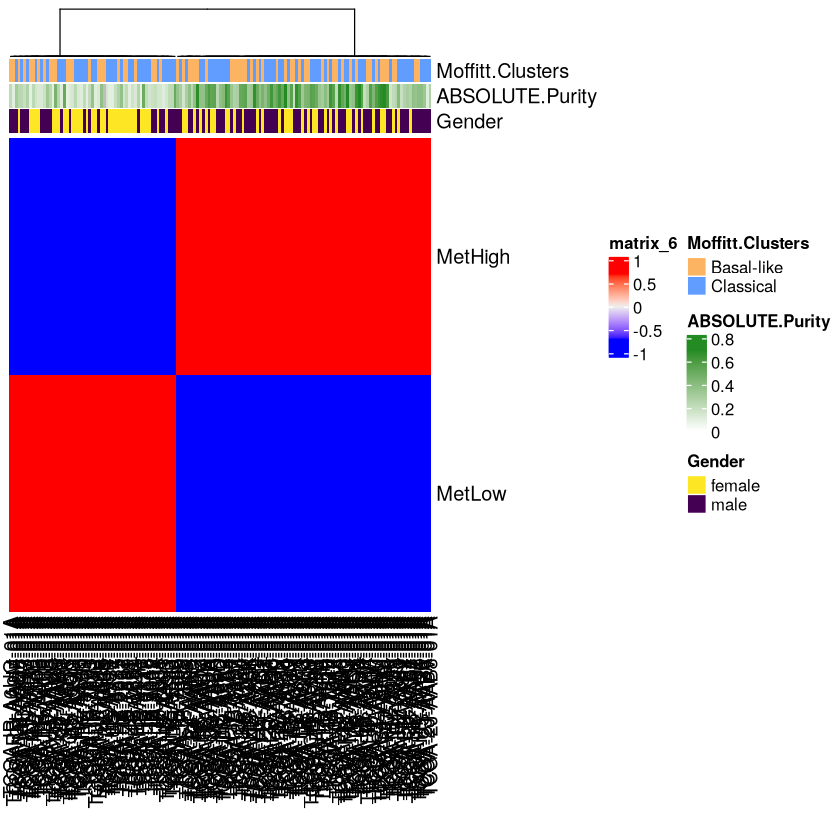

In [17]:


Heatmap(scale(RNA_H), cluster_columns = T, cluster_rows=F,
        ## Set the colors of our features manually
        top_annotation = HeatmapAnnotation(df=subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
                                           col=list(
                                             ABSOLUTE.Purity=colorRamp2(c(0, .7), c("white", "forestgreen")),
                                             Moffitt.Clusters = c("Basal-like"="#fdb462","Classical"="#619cff"),
                                             Gender=c("male"="#440154", "female"="#fde725")
                                           ))
)